# Surfaces

In [2]:
import pandas as pd
import numpy as np
from math import sqrt, pi, exp
from arch import arch_model
import yfinance as yf 
from scipy.optimize import minimize
import warnings
from arch.__future__ import reindexing
from arch.utility.exceptions import ConvergenceWarning
from src.mfiv import MFIVFiniteGridDailyNearestExpiry
from tqdm import tqdm

# suppress optimizer & runtime warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message="y is poorly scaled")
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)


In [7]:
import sys, os
sys.path.insert(0, "/Users/shah/CODE_BOOK_4/THESIS_WORKING/THESIS_2")
sys.modules.pop("src", None)
os.chdir("/Users/shah/CODE_BOOK_4/THESIS_WORKING/THESIS_2")



In [8]:
import plotly.io as pio, plotly.graph_objects as go

In [9]:
# import sys
# !{sys.executable} -m pip install plotly

# Options Data

In [10]:
df = pd.read_parquet("../data/rawData/derivative_data_2021.parquet")

In [11]:
df_copy = df.copy()

In [12]:
df.instrument_name[0]

'BTC-30DEC22-50000-C'

In [13]:
df["strike"] = df["instrument_name"].str.split("-").str[2].astype(float)
df["type"] = df["instrument_name"].str.split("-").str[3].astype(str)
df["option_price"] = df.price * df.index_price


In [14]:
# get maturity from instrument_name
df["maturity"] = pd.to_datetime(df.instrument_name.str.split("-").str[1], format = "%d%b%y")
df.maturity

0         2022-12-30
1         2022-06-24
2         2022-06-24
3         2022-03-25
4         2022-01-07
             ...    
2936009   2021-01-15
2936010   2021-01-08
2936011   2021-01-01
2936012   2021-01-08
2936013   2021-01-01
Name: maturity, Length: 2936014, dtype: datetime64[us]

In [15]:
df[['type','date_time', 'strike', 'option_price', 'maturity','index_price']]

,type,date_time,strike,option_price,maturity,index_price
0,C,2022-01-01 22:58:53.815,50000.0,14236.008000,2022-12-30,47453.36
1,C,2022-01-01 22:56:58.017,250000.0,213.517980,2022-06-24,47448.44
2,C,2022-01-01 22:54:29.448,50000.0,9180.721665,2022-06-24,47445.59
3,C,2022-01-01 22:54:19.829,70000.0,1541.626775,2022-03-25,47434.67
4,P,2022-01-01 22:52:56.446,47000.0,1280.541420,2022-01-07,47427.46
...,...,...,...,...,...,...
2936009,P,2020-12-31 23:02:13.305,30000.0,2551.385760,2021-01-15,28993.02
2936010,P,2020-12-31 23:02:08.551,25500.0,406.298340,2021-01-08,29021.31
2936011,C,2020-12-31 23:02:07.090,29500.0,87.104730,2021-01-01,29034.91
2936012,P,2020-12-31 23:01:54.315,26000.0,479.288370,2021-01-08,29047.78


In [16]:
# # SAVE
# file_path = ("../ms_garch_mdls/data/dfOptions.parquet")
# df.to_parquet(file_path)

# Load df

In [17]:
# file_path = ("../ms_garch_mdls/data/dfOptions.parquet")
# df = pd.read_parquet(file_path)

In [18]:
df.columns

Index(['trade_seq', 'trade_id', 'timestamp', 'tick_direction', 'price',
       'mark_price', 'iv', 'instrument_name', 'index_price', 'direction',
       'amount', 'block_trade_id', 'liquidation', 'date_time', 'strike',
       'type', 'option_price', 'maturity'],
      dtype='str')

# Compute Surface

In [19]:
##### added later, with tqdm
import numpy as np, pandas as pd
from tqdm import tqdm

d = df.copy()
d["day"] = pd.to_datetime(d["date_time"], utc=True).dt.floor("h")
d["maturity"] = pd.to_datetime(d["maturity"], utc=True)
d["T"] = (d["maturity"] - d["day"]).dt.total_seconds() / (365.25*24*3600)
d["m"] = d["strike"] / d["index_price"]
d = d[(d["T"] > 0) & np.isfinite(d["iv"]) & np.isfinite(d["m"])]

T_bins = np.array([0, 7/365.25, 14/365.25, 30/365.25, 60/365.25, 90/365.25, 180/365.25, 1, 2, 5])
m_bins = np.array([0.5, 0.7, 0.85, 0.95, 1.0, 1.05, 1.15, 1.3, 1.6, 2.0])

d["T_bin"] = pd.cut(d["T"], T_bins, include_lowest=True)
d["m_bin"] = pd.cut(d["m"], m_bins, include_lowest=True)

gobj = d.groupby("day", sort=True)
surfaces_1d = {}
for day, g in tqdm(gobj, total=gobj.ngroups):
    surfaces_1d[day] = g.pivot_table(index="T_bin", columns="m_bin", values="iv", aggfunc="mean", observed=False)


100%|██████████| 8782/8782 [00:17<00:00, 514.84it/s]


### CHECKS

(-0.001, 0.0192] = 0 to 7 days<br>
(0.0192, 0.0383] = 7 to 14 days<br>
(0.0383, 0.0821] = 14 to 30 days<br>

In [20]:
# It sorts the dictionary keys and returns second key, meaning day 2
surfaces_1d[sorted(surfaces_1d)[1]]

m_bin,"(0.499, 0.7]","(0.7, 0.85]","(0.85, 0.95]","(0.95, 1.0]","(1.0, 1.05]","(1.05, 1.15]","(1.15, 1.3]","(1.3, 1.6]","(1.6, 2.0]"
T_bin,,,,,,,,,
"(-0.001, 0.0192]",NaN,126.211111,114.596346,100.164222,96.017143,98.4100,103.434286,134.51,NaN
"(0.0192, 0.0383]",NaN,NaN,96.590000,93.220000,NaN,NaN,NaN,NaN,NaN
"(0.0383, 0.0821]",123.635000,100.382000,95.298519,NaN,90.660000,91.6900,96.282000,101.59,127.846667
"(0.0821, 0.164]",98.801429,93.890000,NaN,NaN,93.095000,NaN,NaN,NaN,NaN
"(0.164, 0.246]",92.120000,89.737059,NaN,91.094231,NaN,94.5075,96.690000,NaN,NaN
"(0.246, 0.493]",NaN,87.980000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"(0.493, 1.0]",NaN,NaN,NaN,NaN,NaN,77.8100,NaN,NaN,NaN


## View Surface

### Surface per hour.

In [21]:
import plotly.io as pio, plotly.graph_objects as go
pio.renderers.default = "browser"
# random days sliced
for i in range (310,315):
    day = sorted(surfaces_1d.keys())[i]
    g = surfaces_1d[day]
    X, Y = np.meshgrid([c.mid for c in g.columns], [i.mid for i in g.index])

    fig = go.Figure(go.Surface(x=X, y=Y, z=g.values))

    fig.update_layout(title=day.strftime("%Y-%m-%d"))
    fig.update_layout(
        scene=dict(
            xaxis_title="x_Moneyness",
            yaxis_title="y_Time to Maturity",
            zaxis_title="z_Implied Volatility"
        )
    )

    fig.show()


### Average Surface of 2021 (btc)

In [22]:
### Tighter moneyness bins 
import numpy as np, pandas as pd
from tqdm import tqdm

d = df.copy()
d["day"] = pd.to_datetime(d["date_time"], utc=True).dt.floor("h")
d["maturity"] = pd.to_datetime(d["maturity"], utc=True)
d["T"] = (d["maturity"] - d["day"]).dt.total_seconds() / (365.25*24*3600)
d["m"] = d["strike"] / d["index_price"]
d = d[(d["T"] > 0) & np.isfinite(d["iv"]) & np.isfinite(d["m"])]

T_bins = np.array([0, 7/365.25, 14/365.25, 30/365.25, 60/365.25, 90/365.25, 180/365.25, 1, 2, 5])
# m_bins = np.array([0.95, 0.96, 0.97, 0.98, 0.99, 1.0, 1.01, 1.02, 1.03, 1.04, 1.05])
m_bins = np.arange(0.5, 2.01, 0.01)

d["T_bin"] = pd.cut(d["T"], T_bins, include_lowest=True)
d["m_bin"] = pd.cut(d["m"], m_bins, include_lowest=True)

gobj = d.groupby("day", sort=True)
surfaces_1d = {}
for day, g in tqdm(gobj, total=gobj.ngroups):
    surfaces_1d[day] = g.pivot_table(index="T_bin", columns="m_bin", values="iv", aggfunc="mean", observed=False)


100%|██████████| 8782/8782 [00:20<00:00, 431.41it/s]


In [21]:
import plotly.io as pio, plotly.graph_objects as go
import numpy as np

pio.renderers.default = "browser"

# take a reference grid
ref = list(surfaces_1d.values())[0]
common_index = ref.index
common_columns = ref.columns

aligned = []
for g in surfaces_1d.values():
    g2 = g.reindex(index=common_index, columns=common_columns)
    aligned.append(g2)

avg_surface = np.nanmean([g.values for g in aligned], axis=0)

X, Y = np.meshgrid(
    [c.mid for c in common_columns],
    [i.mid for i in common_index]
)

fig = go.Figure(go.Surface(x=X, y=Y, z=avg_surface))

fig.update_layout(
    title="average surface of the year",
    scene=dict(
        xaxis_title="x_Moneyness",
        yaxis_title="y_Time to Maturity",
        zaxis_title="z_Implied Volatility"
    )
)

fig.show()

The above surface of 2021 is high dimensional, the same analysis below on 2019 is not as granular.
2019 unfit for inference 
AXES CLARITY :
X : moneyness grid (from g.columns)
Y : time-to-maturity grid
Z : implied volatility values

### Average Surface of 2019 (btc)

In [24]:
df = pd.read_parquet("../data/rawData/derivative_data_2019.parquet")

In [25]:
df["strike"] = df["instrument_name"].str.split("-").str[2].astype(float)
df["type"] = df["instrument_name"].str.split("-").str[3].astype(str)
df["option_price"] = df.price * df.index_price

# get maturity from instrument_name
df["maturity"] = pd.to_datetime(df.instrument_name.str.split("-").str[1], format = "%d%b%y")
df.maturity

0        2020-01-10
1        2020-01-31
2        2020-01-31
3        2020-01-03
4        2020-01-03
            ...    
432956   2019-01-25
432957   2019-01-04
432958   2019-01-04
432959   2019-01-04
432960   2019-01-04
Name: maturity, Length: 432961, dtype: datetime64[us]

In [26]:
### Tighter moneyness bins 
import numpy as np, pandas as pd
from tqdm import tqdm

d = df.copy()
d["day"] = pd.to_datetime(d["date_time"], utc=True).dt.floor("h")
d["maturity"] = pd.to_datetime(d["maturity"], utc=True)
d["T"] = (d["maturity"] - d["day"]).dt.total_seconds() / (365.25*24*3600)
d["m"] = d["strike"] / d["index_price"]
d = d[(d["T"] > 0) & np.isfinite(d["iv"]) & np.isfinite(d["m"])]

T_bins = np.array([0, 7/365.25, 14/365.25, 30/365.25, 60/365.25, 90/365.25, 180/365.25, 1, 2, 5])
# m_bins = np.array([0.95, 0.96, 0.97, 0.98, 0.99, 1.0, 1.01, 1.02, 1.03, 1.04, 1.05])
m_bins = np.arange(0.5, 2.01, 0.01)

d["T_bin"] = pd.cut(d["T"], T_bins, include_lowest=True)
d["m_bin"] = pd.cut(d["m"], m_bins, include_lowest=True)

gobj = d.groupby("day", sort=True)
surfaces_1d = {}
for day, g in tqdm(gobj, total=gobj.ngroups):
    surfaces_1d[day] = g.pivot_table(index="T_bin", columns="m_bin", values="iv", aggfunc="mean", observed=False)


100%|██████████| 8767/8767 [00:17<00:00, 510.27it/s]


In [27]:
import plotly.io as pio, plotly.graph_objects as go
import numpy as np

pio.renderers.default = "browser"

# take a reference grid
ref = list(surfaces_1d.values())[0]
common_index = ref.index
common_columns = ref.columns

aligned = []
for g in surfaces_1d.values():
    g2 = g.reindex(index=common_index, columns=common_columns)
    aligned.append(g2)

avg_surface = np.nanmean([g.values for g in aligned], axis=0)

X, Y = np.meshgrid(
    [c.mid for c in common_columns],
    [i.mid for i in common_index]
)

fig = go.Figure(go.Surface(x=X, y=Y, z=avg_surface))

fig.update_layout(
    title="average surface of the year",
    scene=dict(
        xaxis_title="x_Moneyness",
        yaxis_title="y_Time to Maturity",
        zaxis_title="z_Implied Volatility"
    )
)

fig.show()

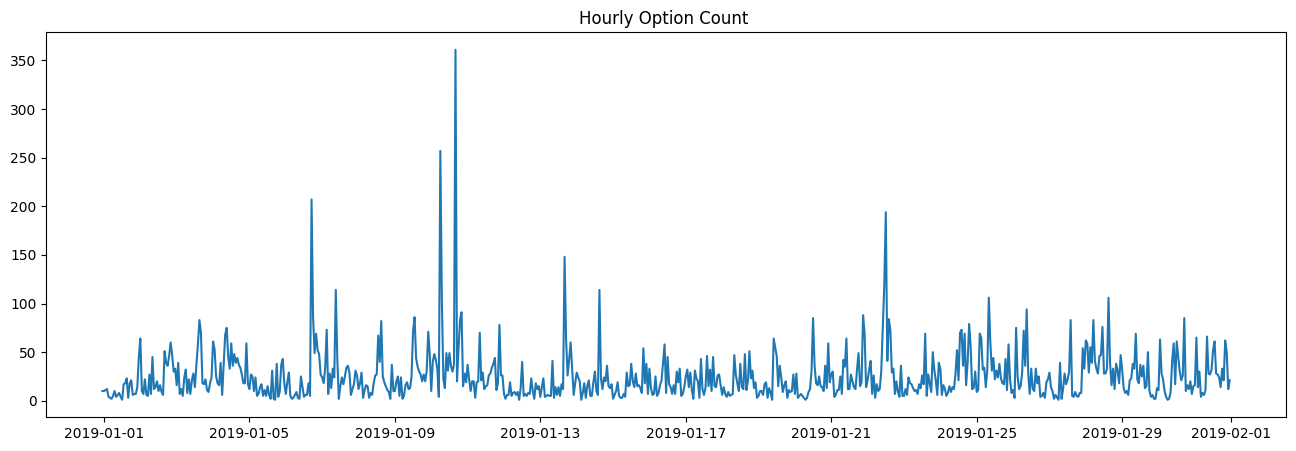

In [28]:
import matplotlib.pyplot as plt
df_clipped = df[pd.to_datetime(df["date_time"], utc=True) < pd.to_datetime("2019-02-01", utc=True)]
counts = df_clipped.groupby(pd.to_datetime(df_clipped["date_time"]).dt.floor("h")).size()
plt.figure(figsize=(16, 5))
plt.plot(counts.index, counts.values)
plt.title("Hourly Option Count ")
plt.show()

The option counts here account for a very short range of strikes, which are unstable over 2019.
This is also observed in the density of the IV surfaces computed below.

### MFIV for high frequencies

In [14]:
from src.mfiv import MFIVFiniteGridDailyNearestExpiry

mfiv = MFIVFiniteGridDailyNearestExpiry()
result = mfiv.compute_daily(df, r=0.05, min_strikes=2)
result.head(5)

,date,asof_time,expiry_used,T_years,T_days,T_minutes,S0,F0,Kmin,Kmax,mfiv_var,mfiv_vol,n_strikes
0,2025-01-05 00:00:00+00:00,2025-01-05 23:46:00+00:00,2025-01-31 00:00:00+00:00,0.068520,25.009722,36014.0,98366.90,98704.481897,108000.0,112000.0,0.001660,0.155626,2
1,2025-01-11 00:00:00+00:00,2025-01-11 23:30:00+00:00,2025-01-31 00:00:00+00:00,0.052112,19.020833,27390.0,94615.59,94862.441234,93000.0,115000.0,0.010219,0.442822,3
2,2025-01-20 00:00:00+00:00,2025-01-20 23:58:00+00:00,2025-02-28 00:00:00+00:00,0.104113,38.001389,54722.0,101993.27,102525.597635,106000.0,150000.0,0.019424,0.431938,3
3,2025-01-22 00:00:00+00:00,2025-01-22 23:58:00+00:00,2025-02-28 00:00:00+00:00,0.098634,36.001389,51842.0,103641.32,104153.710036,110000.0,120000.0,0.006861,0.263752,2
4,2025-01-25 00:00:00+00:00,2025-01-25 23:53:00+00:00,2025-02-28 00:00:00+00:00,0.090424,33.004861,47527.0,104831.84,105306.880237,110000.0,115000.0,0.003672,0.201529,2


### Model-Free Implied Volatility (MFIV) computed by the class

**Inputs**
- Spot price $(S_0)$
- Forward price $F_0 = S_0 e^{(r-q)T}$
- Call option prices $C(K,T)$ across strikes $K$
- Time to expiry $T$
<br>

**MFIV variance formula**
$$
\text{MFIV}_T^2
=
\frac{2}{T}
\int_{0}^{\infty}
\frac{C_F(K,T) - \max(F_0 - K, 0)}{K^2}\, dK
$$
where $$C_F(K,T) = C(K,T)e^{rT}$$ is the forward-price call.

**Why integrate over strikes**
- Integration aggregates information from **all available strikes**.
- This removes model assumptions and recovers **risk-neutral variance**.

**Output**
- **mfiv_var**: model-free implied variance over horizon \(T\).
- **mfiv_vol**: $\sqrt{\text{mfiv\_var}}$, the annualized MFIV.


### Create Surface

In [3]:
def create_surface(df):
    d = df.copy()
    d["maturity"] = pd.to_datetime(df.instrument_name.str.split("-").str[1], format = "%d%b%y")
    d["strike"] = d["instrument_name"].str.split("-").str[2].astype(float)
    d["type"] = d["instrument_name"].str.split("-").str[3].astype(str)
    d["option_price"] = d.price * d.index_price

    d["day"] = pd.to_datetime(d["date_time"], utc=True).dt.floor("1h")
    d["maturity"] = pd.to_datetime(d["maturity"], utc=True)
    d["T"] = (d["maturity"] - d["day"]).dt.total_seconds() / (365.25*24*3600)
    d["m"] = d["strike"] / d["index_price"]
    d = d[(d["T"] > 0) & np.isfinite(d["iv"]) & np.isfinite(d["m"])]

    T_bins = np.array([0, 7/365.25, 14/365.25, 30/365.25, 60/365.25, 90/365.25, 180/365.25, 1, 2, 5])
    m_bins = np.array([0.5, 0.7, 0.85, 0.95, 1.0, 1.05, 1.15, 1.3, 1.6, 2.0])

    d["T_bin"] = pd.cut(d["T"], T_bins, include_lowest=True)
    d["m_bin"] = pd.cut(d["m"], m_bins, include_lowest=True)

    gobj = d.groupby("day", sort=True)
    surfaces_1d = {}
    for day, g in tqdm(gobj, total=gobj.ngroups):
        surfaces_1d[day] = g.pivot_table(index="T_bin", columns="m_bin", values="iv", aggfunc="mean", observed=False)
    
    return gobj, surfaces_1d



In [9]:
import pandas as pd
df = pd.read_parquet("../data/rawData/derivative_data_2019.parquet")

In [5]:
gobj_22, surfaces_1d_22 = create_surface(df)

100%|██████████| 8784/8784 [00:17<00:00, 516.47it/s]


In [7]:
import plotly.io as pio, plotly.graph_objects as go
pio.renderers.default = "browser"
# 250,300
for i in range (300,330):
    day = sorted(surfaces_1d_22.keys())[i]
    g = surfaces_1d_22[day]
    X, Y = np.meshgrid([c.mid for c in g.columns], [i.mid for i in g.index])

    fig = go.Figure(go.Surface(x=X, y=Y, z=g.values))

    fig.update_layout(title=day.strftime("%Y-%m-%d"))
    fig.update_layout(
        scene=dict(
            xaxis_title="x_Moneyness",
            yaxis_title="y_Time to Maturity",
            zaxis_title="z_Implied Volatility"
        )
    )

    fig.show()
